In [1]:
import os
print(os.getcwd())

/Users/dts/projects/protein-function-ml/notebooks


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

bundle = joblib.load("../models/best_model.joblib")
model = bundle["model"]
label_encoder = bundle["label_encoder"]
feature_cols = bundle["feature_cols"]
print("Loaded model:", bundle["model_name"])

df = pd.read_csv("../data/processed/features.csv")
X = df[feature_cols].values
y = df["function_category"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42,
)

y_test_enc = label_encoder.transform(y_test)
acc = accuracy_score(y_test_enc, model.predict(X_test))
print(f"Reproduced test accuracy: {acc:.3f}")

/usr/local/Caskroom/miniforge/base/envs/proteinfunc/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded model: XGBoost
Reproduced test accuracy: 0.788


In [3]:
explainer = shap.TreeExplainer(model)
explanation = explainer(X_test)

print("SHAP values shape:", explanation.values.shape)
print("Base values shape:", explanation.base_values.shape)

SHAP values shape: (1993, 426, 5)
Base values shape: (1993, 5)


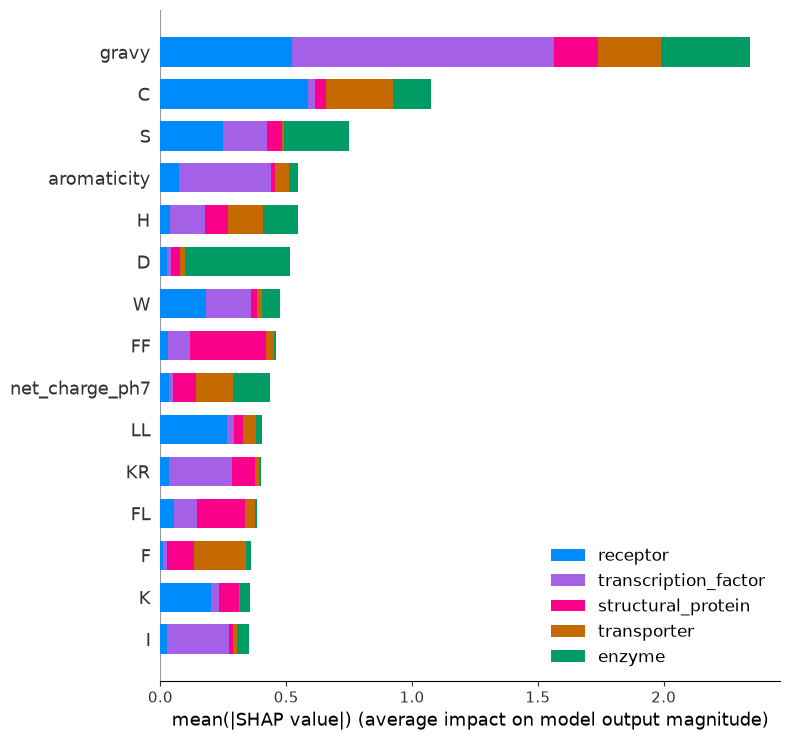

In [4]:
class_names = label_encoder.classes_
shap_values_per_class = [explanation.values[:, :, i] for i in range(len(class_names))]

shap.summary_plot(
    shap_values_per_class, X_test, feature_names=feature_cols,
    plot_type="bar", class_names=class_names, max_display=15, show=False,
)
plt.tight_layout()
plt.savefig("../results/figures/shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
def classify_feature(name):
    if name in set("ACDEFGHIKLMNPQRSTVWY"):
        return "single residue"
    if len(name) == 2 and name.isupper():
        return "dipeptide"
    return "physicochemical"

top_features_by_class = {}
for i, cls in enumerate(class_names):
    mean_abs_shap = np.abs(explanation.values[:, :, i]).mean(axis=0)
    ranking = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False).head(15)
    ranking_df = pd.DataFrame({
        "mean_abs_shap": ranking.round(4),
        "feature_type": [classify_feature(f) for f in ranking.index],
    })
    top_features_by_class[cls] = ranking_df
    print(f"\n=== Top 15 features for {cls} ===")
    print(ranking_df)


=== Top 15 features for enzyme ===
                mean_abs_shap     feature_type
D                      0.4149   single residue
gravy                  0.3557  physicochemical
S                      0.2575   single residue
C                      0.1510   single residue
net_charge_ph7         0.1481  physicochemical
H                      0.1394   single residue
DI                     0.1210        dipeptide
FD                     0.1204        dipeptide
GH                     0.1015        dipeptide
T                      0.0901   single residue
HC                     0.0897        dipeptide
EA                     0.0854        dipeptide
V                      0.0764   single residue
G                      0.0745   single residue
PE                     0.0731        dipeptide

=== Top 15 features for receptor ===
       mean_abs_shap     feature_type
C             0.5848   single residue
gravy         0.5224  physicochemical
LL            0.2666        dipeptide
S             0.2505  

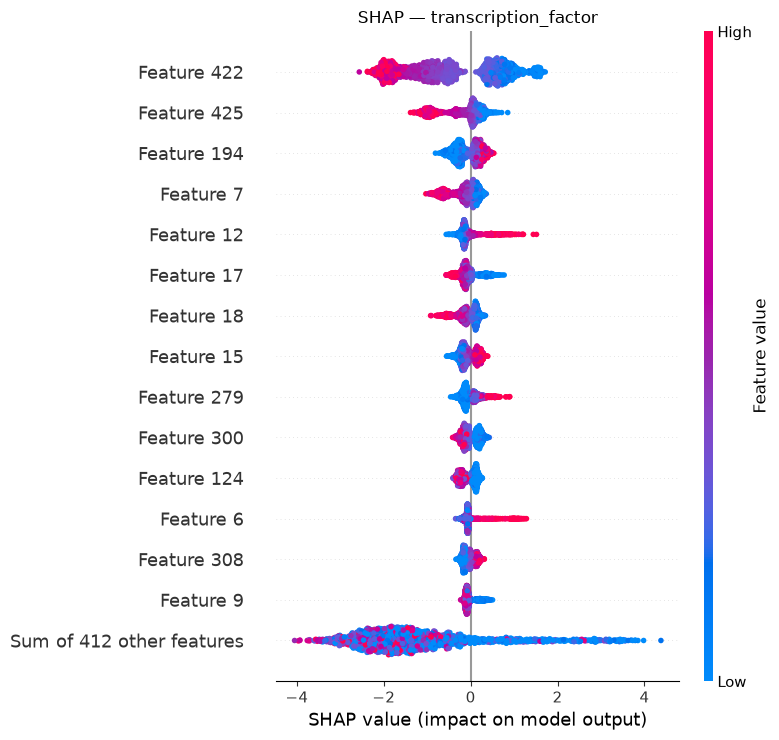

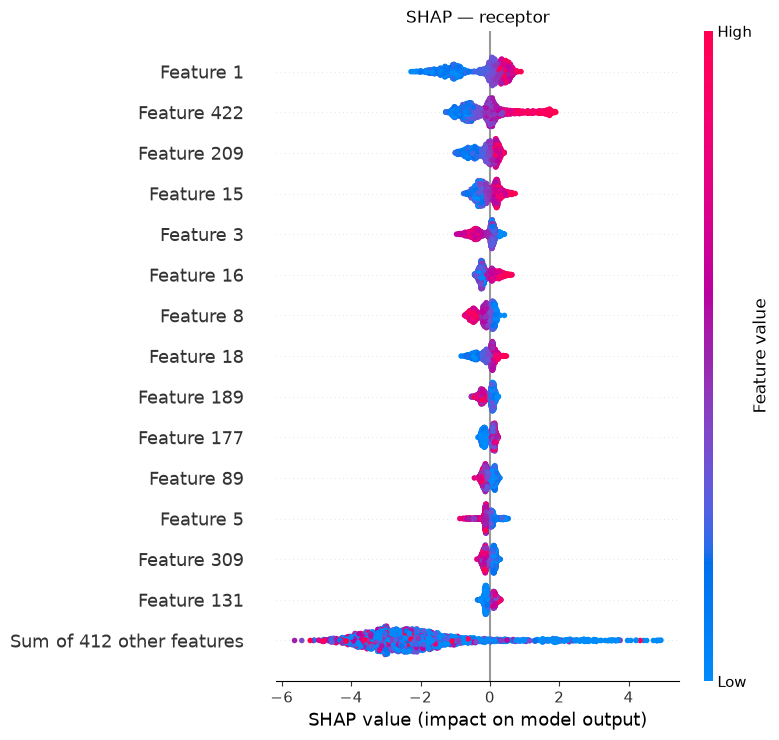

In [6]:
tf_idx = list(class_names).index("transcription_factor")
shap.plots.beeswarm(explanation[:, :, tf_idx], max_display=15, show=False)
plt.title("SHAP — transcription_factor")
plt.tight_layout()
plt.savefig("../results/figures/shap_beeswarm_transcription_factor.png", dpi=150, bbox_inches="tight")
plt.show()

rec_idx = list(class_names).index("receptor")
shap.plots.beeswarm(explanation[:, :, rec_idx], max_display=15, show=False)
plt.title("SHAP — receptor")
plt.tight_layout()
plt.savefig("../results/figures/shap_beeswarm_receptor.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
for cls, ranking_df in top_features_by_class.items():
    ranking_df.to_csv(f"../results/figures/shap_top_features_{cls}.csv")